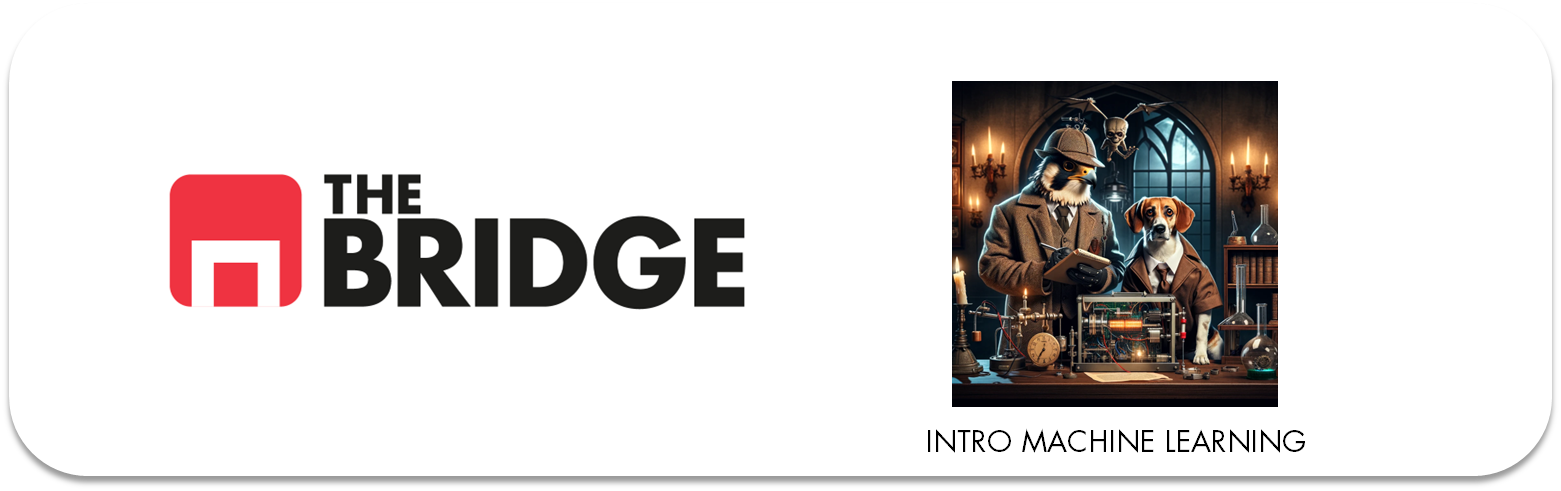

*NOTA: [Adaptado de "Hands-On Machine Learning with Scikit-Learn, Keras, and Tensorflow" de Aurelien Geron]*

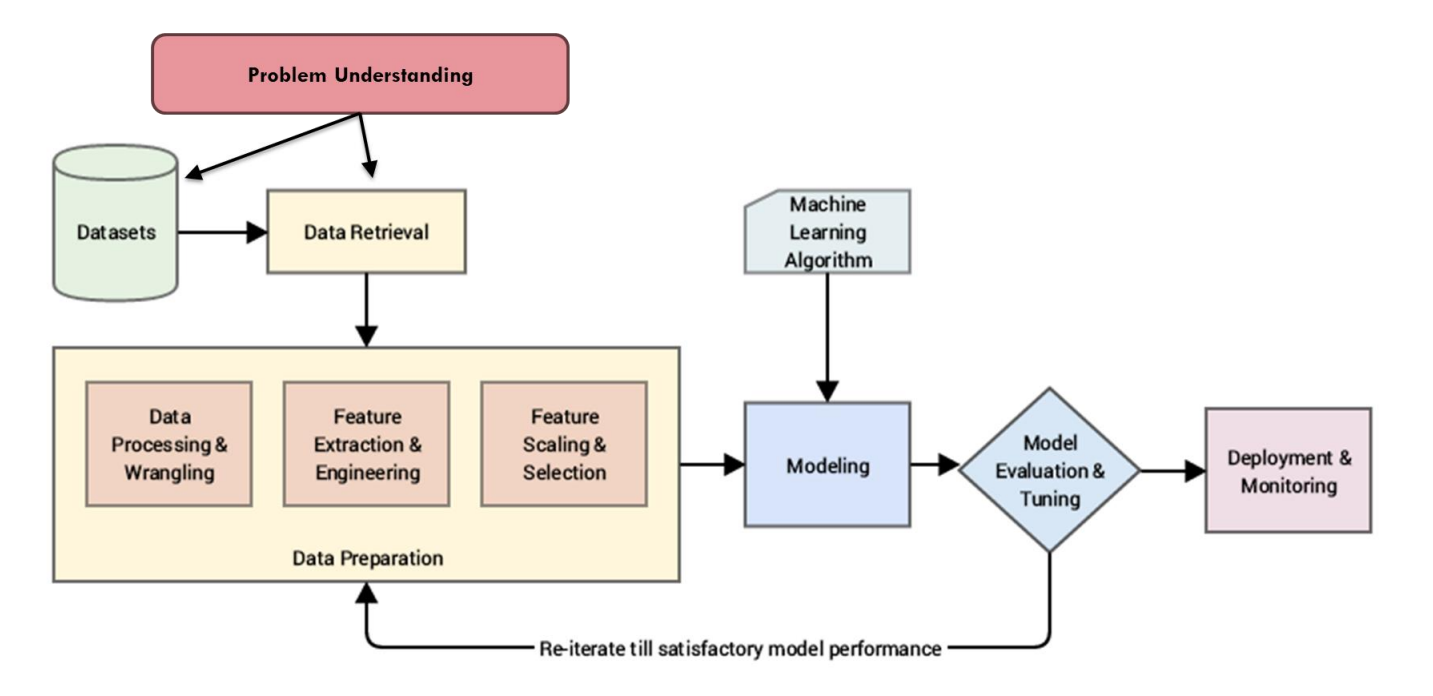

**RESUMEN ETAPAS**

## Flujo de un proyecto de Machine Learning

1. **Problema de negocio → Problema técnico**
   - Traducir la necesidad del negocio a un problema abordable con datos.

2. **Definir el tipo de problema**
   - **Supervisado**: Regresión (objetivo numérico) o Clasificación (objetivo categórico).  
   - **No supervisado**: *Clustering*, reducción de dimensionalidad o detección de anomalías.

3. **Acceso e Ingesta de datos** 
   - Fuentes: BBDD (SQL/NoSQL), APIs, Web Scraping o archivos (CSV, JSON).

4. **Separación de datos: TRAIN / TEST** 
   - **Crucial**: Realizar el split antes del análisis profundo para evitar el *data leakage*.  
   - Uso de división **estratificada** en clasificación para mantener la proporción de clases.

5. **EDA (Análisis Exploratorio de Datos) sobre TRAIN** 
   - Análisis estadístico y visual del **target**.  
   - Detección de correlaciones, valores nulos y *outliers*.  
   - **Feature Engineering**: Creación de nuevas variables basadas en el conocimiento del dominio.

6. **Limpieza y Transformación (Preprocesamiento)**
   - Imputación de nulos y gestión de *outliers* (usando estadísticas calculadas **solo en TRAIN**).  
   - **Encoding**: Convertir variables categóricas a numéricas (OneHot, Ordinal).  
   - **Escalado**: Normalización o estandarización (necesario para modelos como KNN, SVM o Redes Neuronales).

7. **Selección de modelos y métricas (Baseline)** 
   - Establecer un **modelo base** simple.  
   - Definir métricas de éxito: RMSE, MAE (Regresión) o Accuracy, Precision, Recall, F1-Score (Clasificación).

8. **Entrenamiento y Validación Cruzada (Cross-Validation)**
   - Entrenamiento de modelos candidatos.  
   - Uso de *K-Fold Cross-Validation* para asegurar que el rendimiento sea estable y no dependa de un solo split.

9. **Optimización de Hiperparámetros**
   - Búsqueda del mejor conjunto de parámetros mediante *Grid Search*, *Random Search* o *Bayesian Optimization*.  
   - Aplicación de **Regularización** (L1, L2) para controlar el *overfitting* y mejorar la generalización.

10. **Evaluación final en TEST**
    - Evaluación única con el conjunto de datos retenido al principio.  
    - Diagnóstico final: Comparación **Error Train vs. Error Test**.  
    - Si el error en Test es significativamente mayor, existe **overfitting**.



## ML INTRO PRACTICA (I): Fase Inicial 

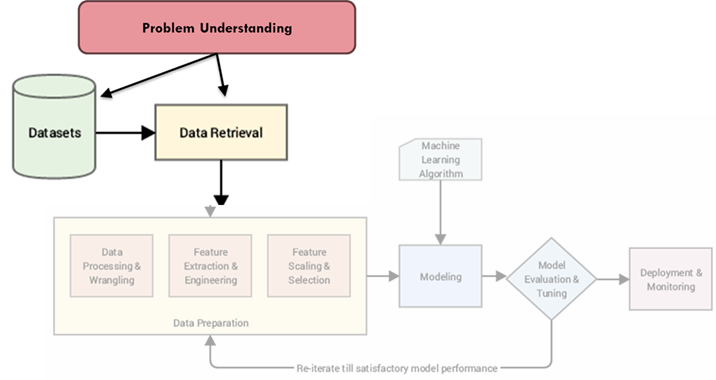

1. Lo primero es saber qué queremos resolver: Problema de negocio vs Problema técnico

2. Lo siguiente es entender que datos tenemos y podemos tener

3. Distinguir entre feature y target

4. Separar entre Train y Test

### 1. El problema de "Negocio"

En nuestro caso la compañía "California Real State Investment Funds" quiere mejorar sus inversiones inmobiliarias para fondos privados. Para ello quiere mejorar su estimación de precios de posibles adquisiciones de viviendas y así escoger mejor sus inversiones y negociar también con ventaja en la adquisición. En concreto le gustaría saber cuál podría ser el precio medio de una casa en una zona de California determinada por una serie de características como su localización, antigüedad media de las casas de la zona, población de la zona, etc.

**Tendremos que traducir nuestro problema de negocio en un problema técnico**

En este caso, parece claro que queremos predecir el precio medio de una casa en una zona determinada. Pero, no vale solo con eso, tendremos que saber en función de qué factores (features) concretos (no sólo una lista "vaga" o "incompleta"), con que margen de error tendríamos un modelo aceptable es decir una métrica de evaluación, tendremos que definir que tipo de aprendizaje (supervisado o no supervisado, por refuerzo...), etc, etc. ¿Cómo se obtiene esto? Preguntando y deduciendo. Lo iremos haciendo poco a poco. Supongamos que ya nos ha contestado al objetivo de negocio y además nos han dicho que nuestro sistema debe ayudar a los analistas de precios que luego introducirán el dato en otro sistema. Estos analistas ya tienen su propia forma de hacer los cálculos, con lo que podrán servirnos como "modelo de referencia" o baseline... Pero son muchas cosas... vayamos por partes... 


Hagamos nuestra cheklist:

* Objetivo de negocio [X] check
* Objetivo tecnico [X] check
* Tipo de modelado (supervisado, no supervisado) [] pending
* Features [] pending
* Target, si hay [] pending
* Tipo de problema (clasificación, regresión, etc) [] pending
* Métrica de Evaluacion [] pending
* Separación Train-Test [] pending


Preguntamos y "California Real State Investment Funds" posee un dataset de muchas zonas con sus precios reales. Y además nos dice que las variables de ese dataset puede tenerlas para cualquier zona futura que quiera valorar.

Pues manos a la obra, hay que conseguir los datos...

### 2. Obtener los datos y echar "un primer vistazo"

Para simplificar este ejemplo, suponemos que tenemos acceso directo a los datos que ese encuentra en un fichero. Es hora de leerlo y antes de importar nuestras librerías (observa que hay un nuevo jugador de equipo):

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from bootcampviztools import pinta_distribucion_categoricas, plot_categorical_numerical_relationship, plot_grouped_histograms

pd.options.mode.copy_on_write = True

# Código extra para los tamaños de las fuentes y los "ticks" de los ejes, esto no lo vimos al hablar de matplotlib así que una extra
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

C:\Users\maria\AppData\Local\Temp\ipykernel_16264\3149107374.py:9: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = True


In [2]:
df_inmo = pd.read_csv("./data/ejemplo_housing.csv")

Como siempre, echaremos un vistazo, pero ojo no podemos hacer más antes de separar en train y test para no "contaminar" nuestro modelo.

In [3]:
df_inmo.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



En este momento deberíamos hacernos nuestra tabla con definiciones, tipo de columna y prioridades... Si estuvieramos haciendo un EDA. Ahora nos llega con la definición y con el tipo de variable. Por simplicidad y tiempo no lo vamos a hacer aquí con detalle. Simplemente ver que la mayoría de las variables o columnas son de tipo numérico continuo salvo esa última "OCEAN_PROXIMITY" a la que echaremos un ojo para entenderla mejor.

In [4]:
df_inmo.info()

<class 'pandas.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
df_inmo["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

Tenemos cinco etiquetas, con frecuencias diferentes. Me lo apunto para luego. Veamos ahora de un golpe las variables numéricas:

In [6]:
df_inmo.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Más que con los valores, con lo que nos quedamos es que son rangos muy variados (de miles, de dolares, en el "median_house_value", hasta unidades y decenas en "median_income"). Esto tendremos que tratarlo como veremos en un par de sesiones, porque a los algoritmos no le suelen sentar bien estas diferencias tan potentes.

Echemos un vistazo, y digo vistazo, porque todavía no podemos tomar números ni hacer análisis univariantes, simplemente veamos la pinta que tienen las variables.

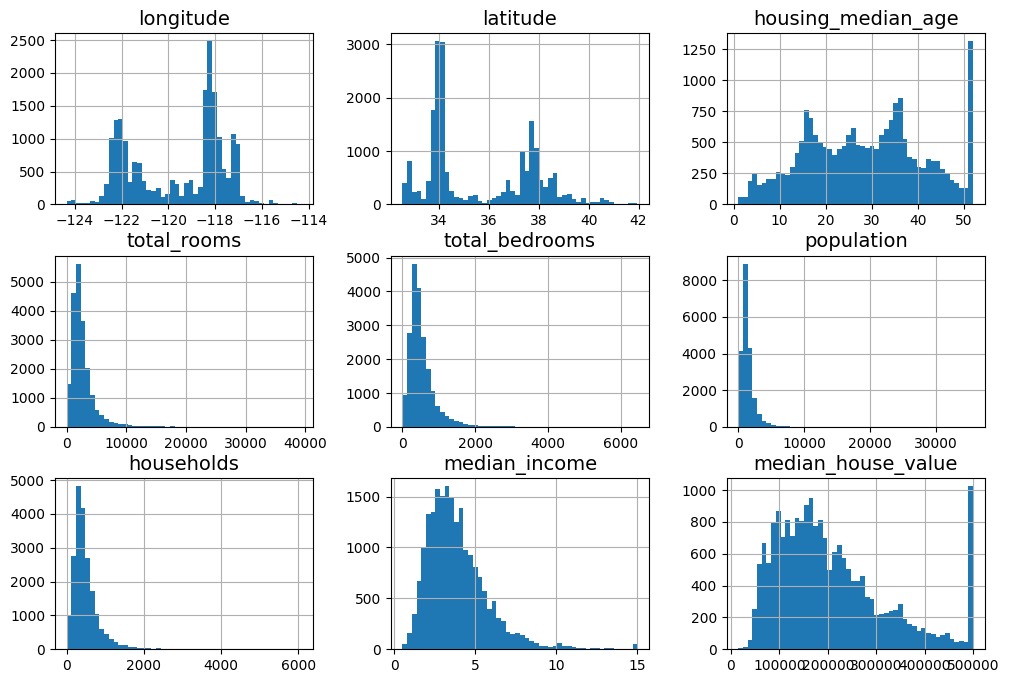

In [7]:

# Código extra para los tamaños de las fuentes y los "ticks" de los ejes, esto no lo vimos al hablar de matplotlib así que una extra
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

df_inmo.hist(bins=50, figsize=(12, 8)) # La forma de generar histogramas de una sola vez para las variables numéricas de un dataset
plt.show()

Y aquí podemos ver:  

1- El ingreso medio ("median_income") esta claro que no está ni en dólares ni en euros. Tendríamos que preguntar a quien nos dio los datos. En este caso nos dirían que el ingreso se ha traducido a una escala de 0 a 15 (dividiendo por 10000 dolares pero además se han limitado las zonas con ingresos medios por encima de 150000 a 15)  
  
2- Existen más variables donde se han "capado" (puesto límite artificial) como "median_house_value" y "housing_median_age". Esto puede ser un problema porque el modelo puede aprender que no debe dar valores por encima de estos. Aquí hay que preguntar a los "jefes" que quieren hacer y tendremos que decidir (buscar los datos exactos para los capados o pasar de estos valores). Lo trataremos en la fase de tratamiento de Features.

3- Se ve que las escalas (ejes x) son muy diferentes como ya habíamos observado en los números.

4- Hay muchas distribuciones tipo "precio del billete" del Titanic, es decir desplazadas a la izquierda y con aparente larga cola. Esto también puede sentarle mal a nuestros algoritmos de modelado y en sprints posteriores veremos como "normalizar" las dsitribuciones de datos para que los algoritmos creen mejores modelos.

Pues hasta aquí el vistazo, no podemos hacer más si no queremos hacernos trampas. Es hora de separar los problemas de estudio de los problemas de examen. Es decir el train del test. Pero antes completemos nuestro checklist.

### 3. Target, Features, tipo de problema

En este caso tenemos una variable que es "claramente" nuestro target (es decir lo que querremos predecir para zonas nuevas): "mean_house_value". 

Además el tener target (la Y del modelo), nos dice que estamos tratando con un modelado supervisado. 

En principio las features serán el resto de variables, pero puede que luego nos descontemos alguna o transformemos otras. 

Y finalmente, queremos predecir una variable continua con lo que estaremos tratando con un problema de regresión.

En nuestra checklist:


* Objetivo de negocio [X] check
* Objetivo tecnico [X] check
* Tipo de modelado (supervisado, no supervisado): SUPERVISADO [X] check
* Features [] pending (aunque tengamos la base no tenemos las defintivas) 
* Target, si hay: "mean_house_value" [X] check
* Tipo de problema (clasificación, regresión, etc): Regresión [X] check
* Métrica de Evaluacion [] pending [podríamos elegirla ya pero lo dejamos para la fase de evaluación para no alargar la sesión demasiado]
* Separación Train-Test [] pending



### 4. Separar Train y Test

Necesitamos tener un dataset para entrenar, pero sobre todo necesitamos un dataset para poder tener una idea de como va a funcionar el modelo cuando le pasemos datos que no ha visto.


¿Y como se crea un set de Test? Generalmente generando dos muestras aleatorias del dataset de partida. Las cifras típicas son un 80% para train y un 20% para test y la forma de hacerlo rápidamente es acudir a la fución que nos hemos importado:

In [8]:
train_set, test_set = train_test_split(df_inmo, test_size=0.2, random_state=42)

In [9]:
y = df_inmo["median_house_value"].copy()
X = df_inmo.drop("median_house_value", axis = 1)

train_set_X, test_set_X, train_set_y, test_set_y = train_test_split(X, y, test_size = 0.2, random_state=42)

In [10]:
len(train_set)

16346

In [11]:
len(test_set)

4087

No podemos ver el test desgraciadamente :-).

Unicamente parece interesante convertir "mean_income" en una variable categórica, porque ya de por sí se ha intentado hacer un escalado con la misma. Esto es algo que ya hicimos varias veces cuando analizamos datos, recurriendo a la función `cut` de pandas. Hagámoslo:


<Axes: >

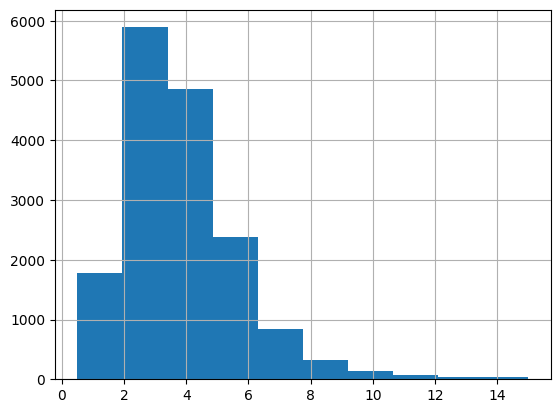

In [12]:
train_set["median_income"].hist()

In [13]:
train_set["income_cat"] = pd.cut(train_set["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

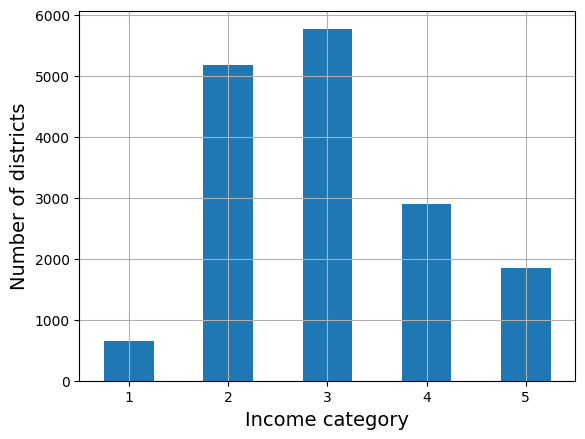

In [14]:
train_set["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [15]:
test_set["income_cat"] = pd.cut(test_set["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

In [16]:
train_set["income_cat"].value_counts(True)

income_cat
3    0.353053
2    0.317019
4    0.176924
5    0.112994
1    0.040010
Name: proportion, dtype: float64

In [17]:
test_set["income_cat"].value_counts(True)

income_cat
3    0.338879
2    0.326156
4    0.175924
5    0.119892
1    0.039149
Name: proportion, dtype: float64

### Estratificado

In [18]:
df_inmo["income_cat"] = pd.cut(df_inmo["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

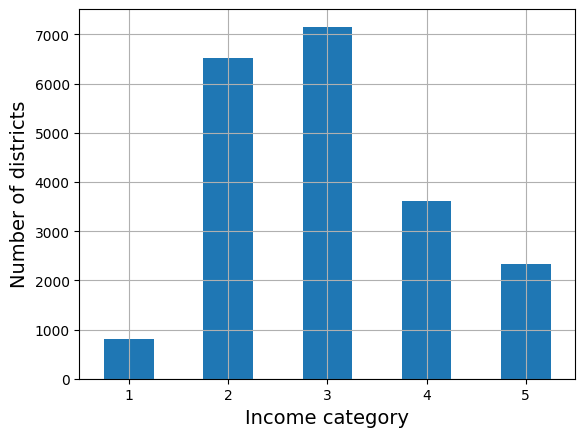

In [19]:
df_inmo["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [20]:
train_set, test_set = train_test_split(df_inmo, test_size= 0.2, random_state= 42, stratify= df_inmo["income_cat"])

In [21]:
train_set.income_cat.value_counts(True)

income_cat
3    0.350239
2    0.318855
4    0.176740
5    0.114340
1    0.039826
Name: proportion, dtype: float64

In [22]:
test_set.income_cat.value_counts(True)

income_cat
3    0.350135
2    0.318816
4    0.176658
5    0.114509
1    0.039883
Name: proportion, dtype: float64

In [23]:
len(train_set)

16346

### Mini-EDA

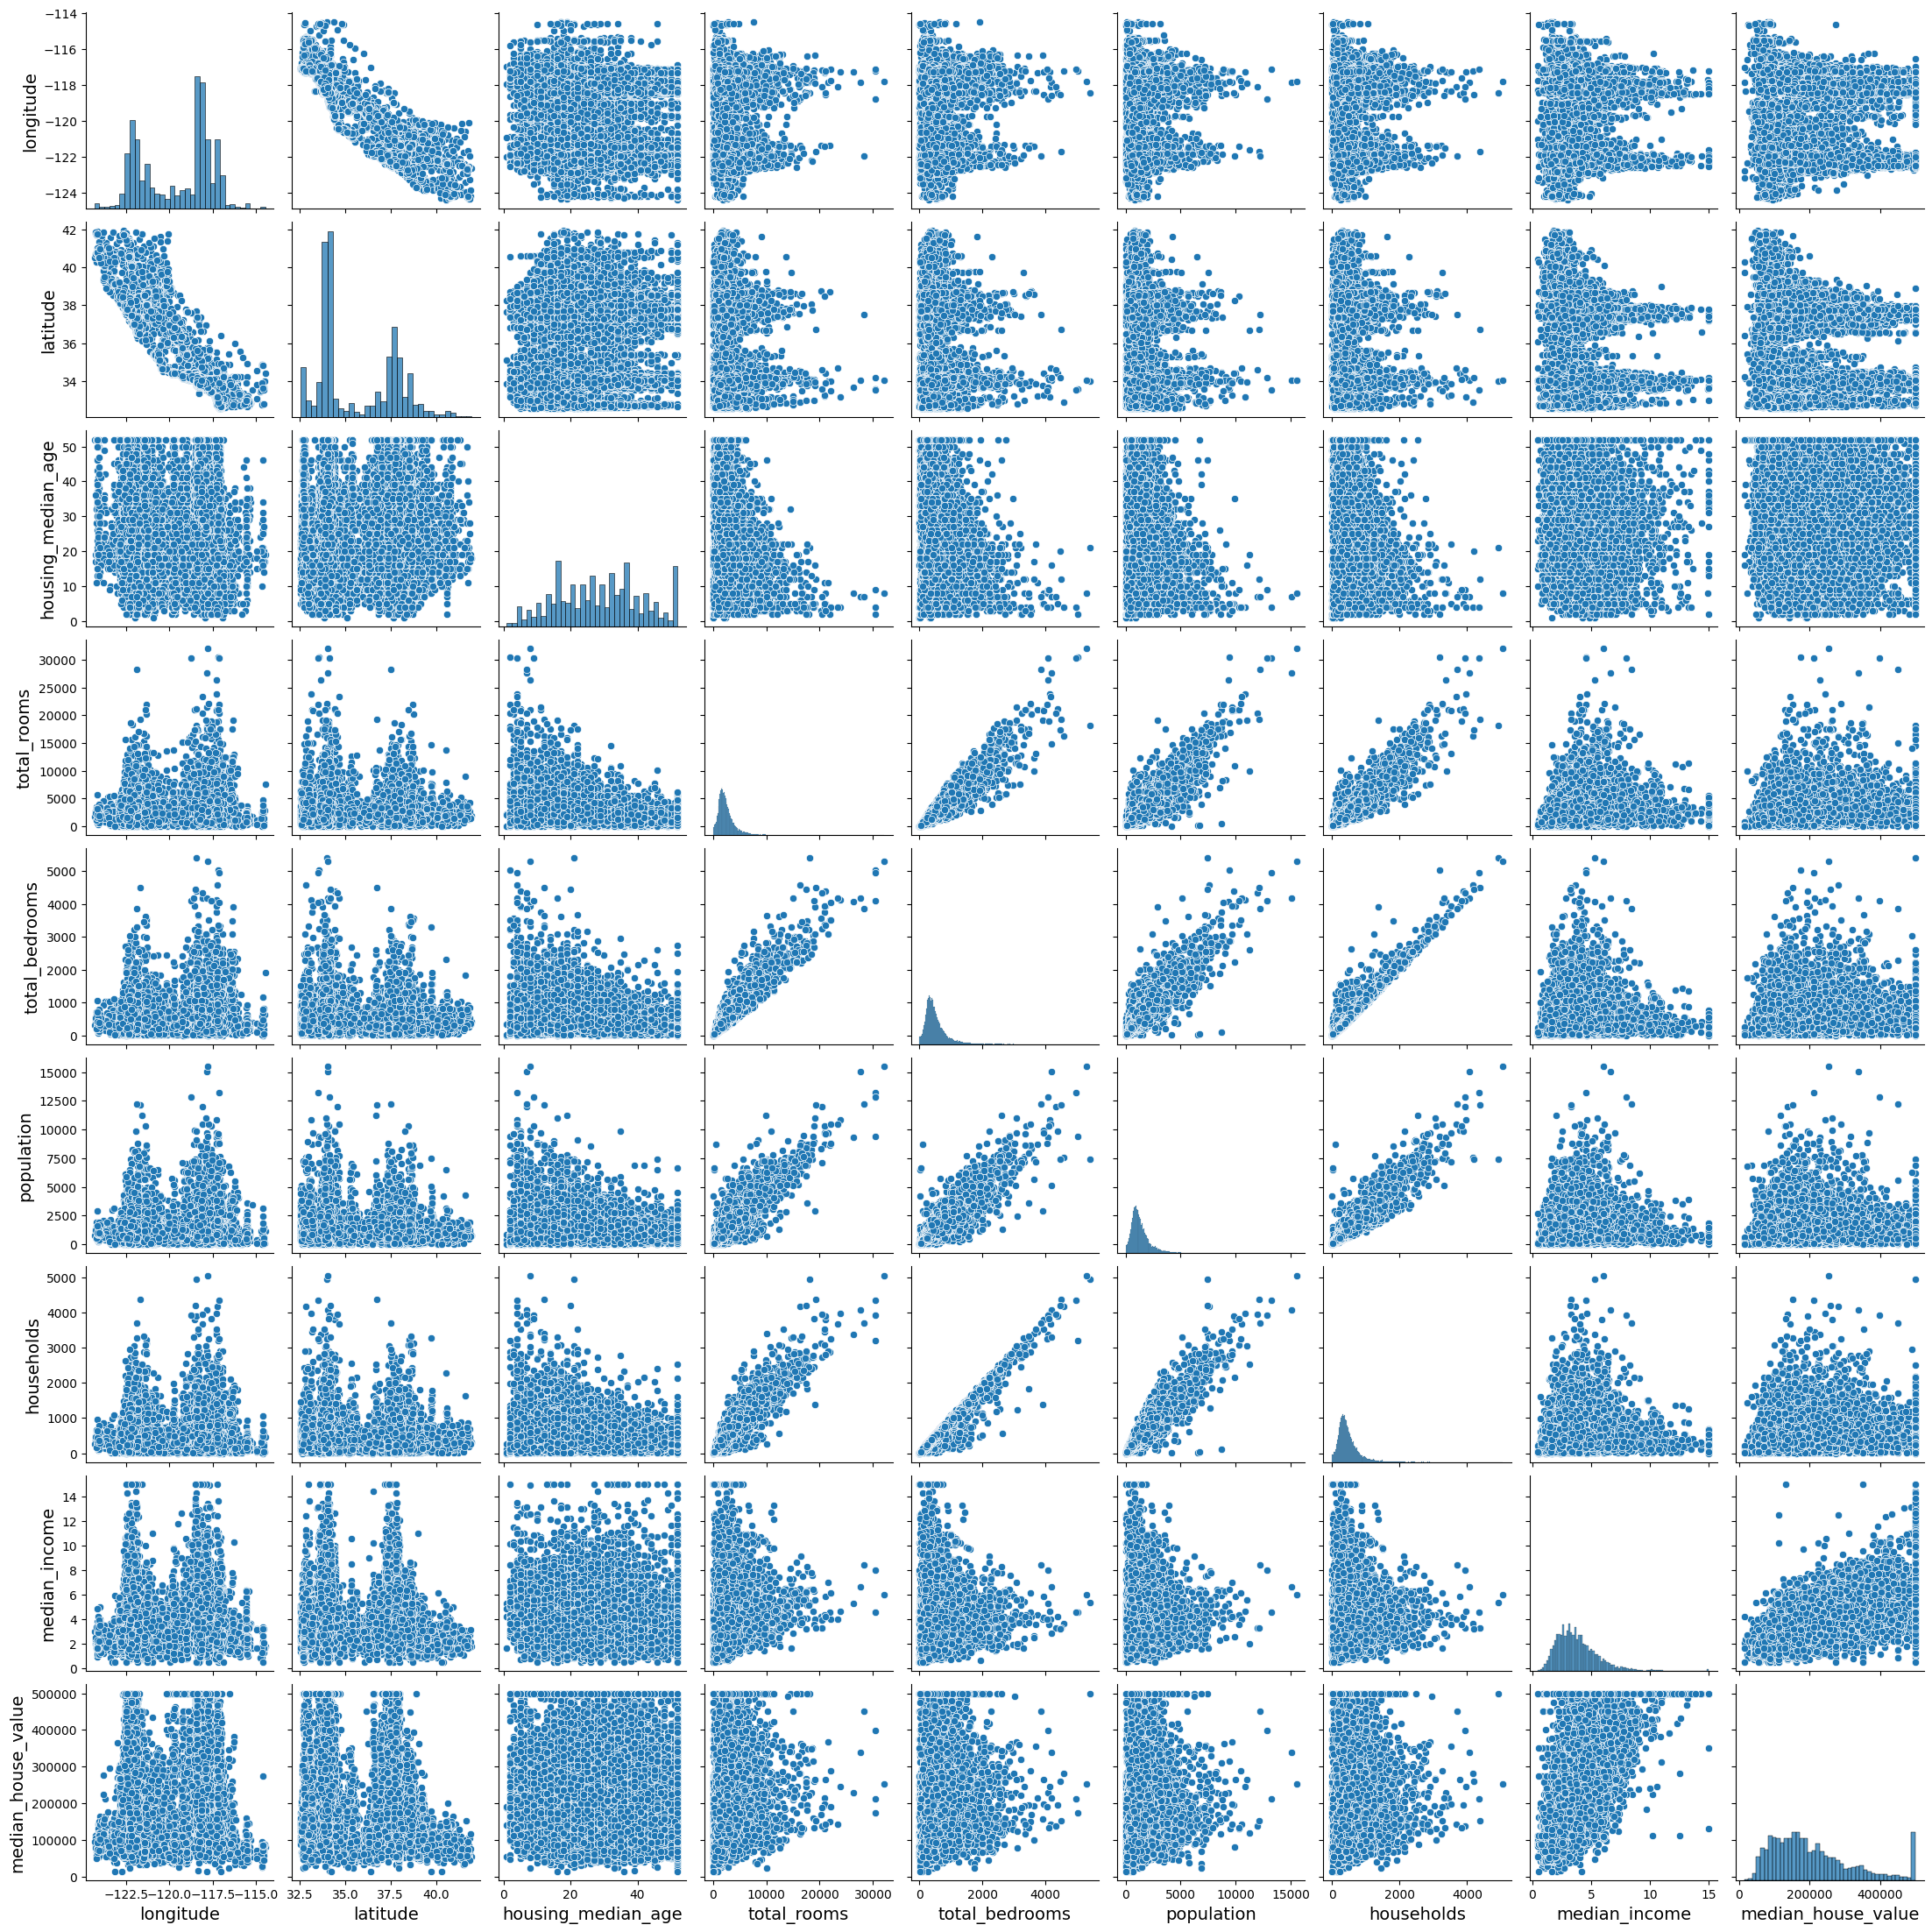

In [24]:
sns.pairplot(train_set)

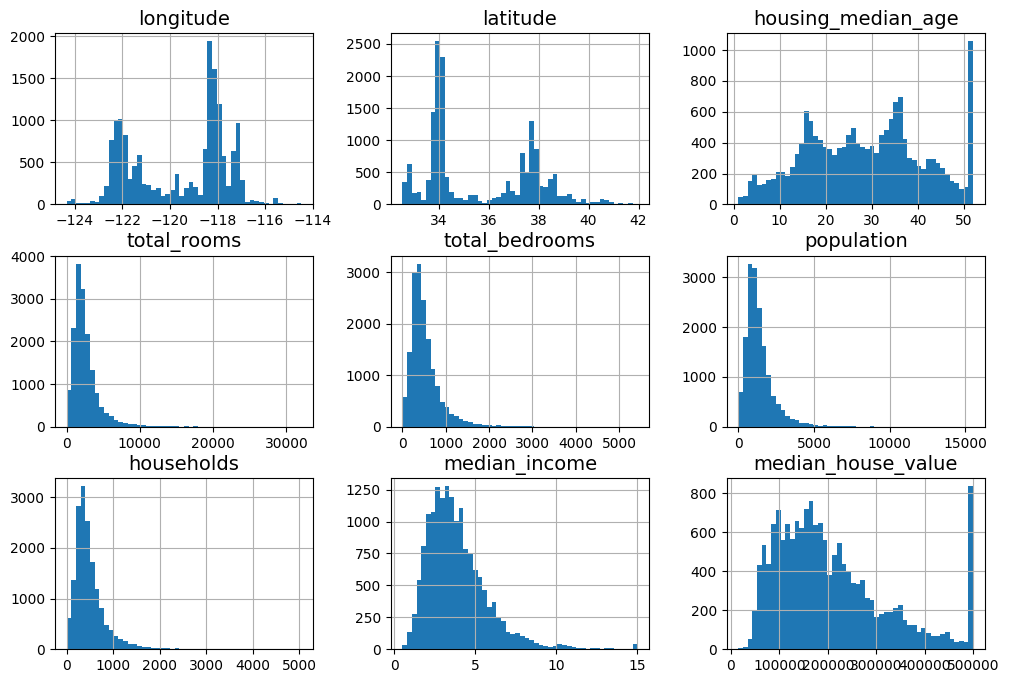

In [25]:
train_set.hist(bins=50, figsize=(12, 8)) # La forma de generar histogramas de una sola vez para las variables numéricas de un dataset
plt.show()

In [26]:
train_set["ocean_proximity"].value_counts()


ocean_proximity
<1H OCEAN     7183
INLAND        5230
NEAR OCEAN    2090
NEAR BAY      1840
ISLAND           3
Name: count, dtype: int64

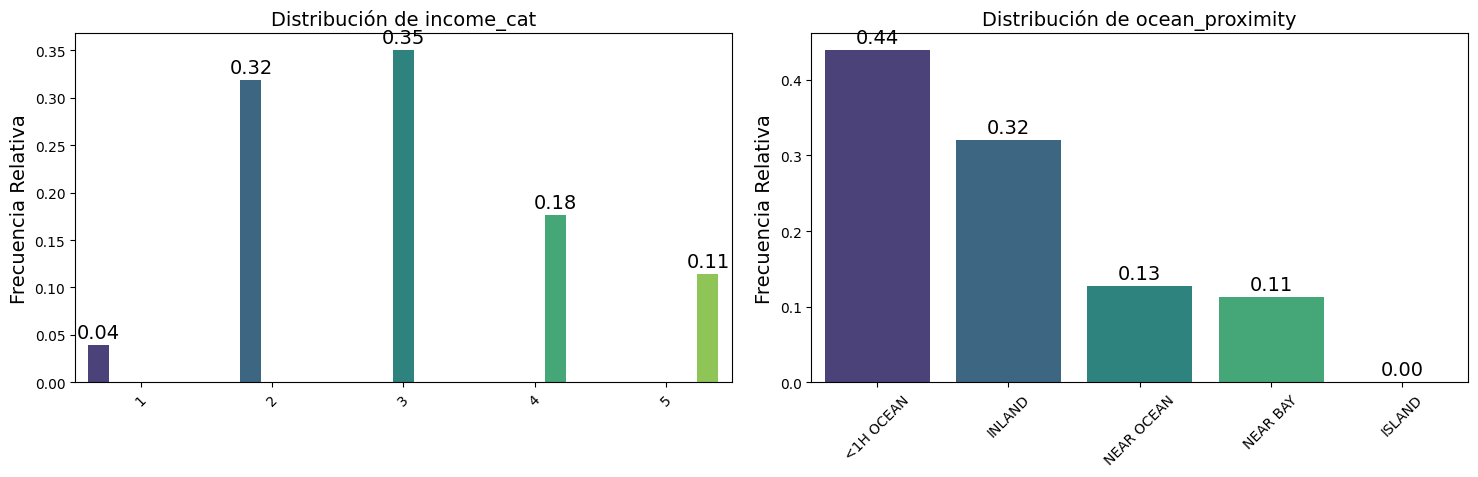

In [27]:
pinta_distribucion_categoricas(train_set, ["income_cat","ocean_proximity"], relativa= True, mostrar_valores= True)

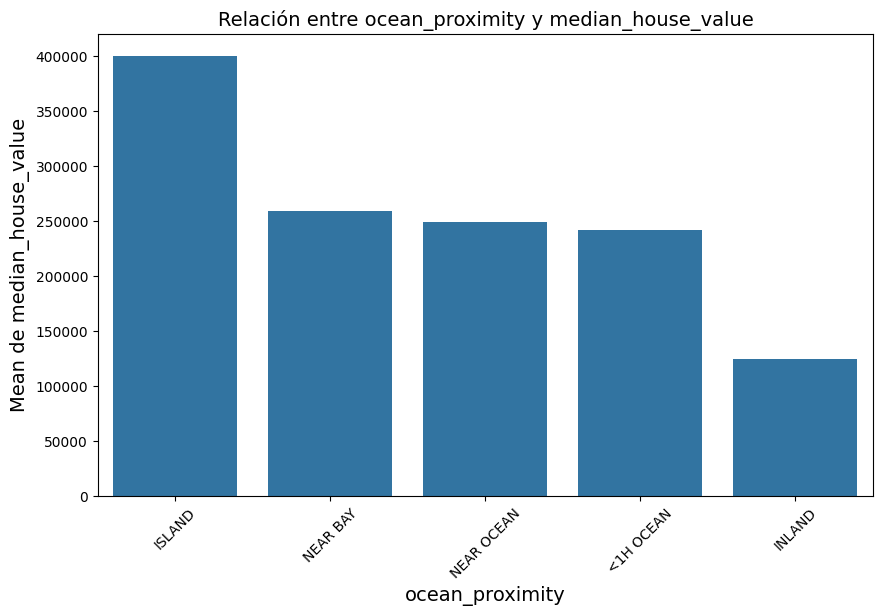

In [28]:
plot_categorical_numerical_relationship(train_set, categorical_col= "ocean_proximity", numerical_col="median_house_value")

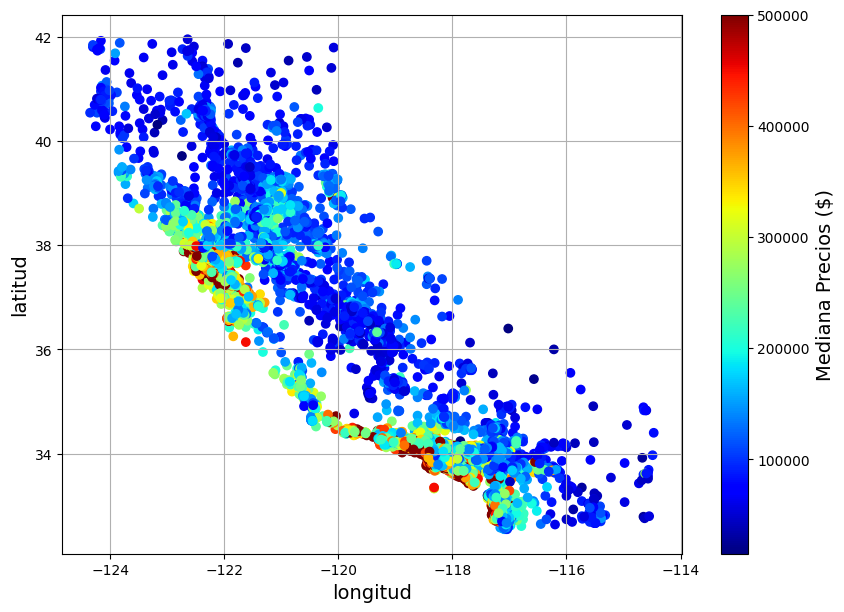

In [29]:
plt.figure(figsize=(10,7))
plt.scatter(train_set["longitude"], train_set["latitude"], c = train_set["median_house_value"], cmap = "jet")
plt.grid()
plt.xlabel("longitud")
plt.ylabel("latitud")
cbar = plt.colorbar(label = "Mediana Precios ($)")

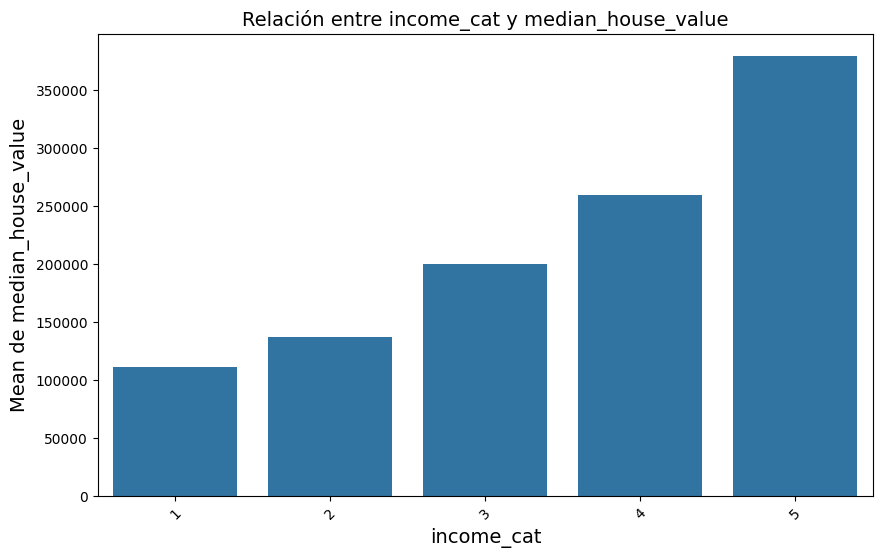

In [30]:
plot_categorical_numerical_relationship(train_set, categorical_col= "income_cat", numerical_col="median_house_value")

In [31]:
corr_matrix = train_set.corr(numeric_only= True)
corr_matrix["median_house_value"].sort_values(ascending = False)

median_house_value    1.000000
median_income         0.690107
total_rooms           0.143421
housing_median_age    0.104802
households            0.075800
total_bedrooms        0.059607
population           -0.014545
longitude            -0.042341
latitude             -0.148180
Name: median_house_value, dtype: float64

In [32]:
columnas = corr_matrix["median_house_value"][corr_matrix["median_house_value"] > 0.07].index.to_list()

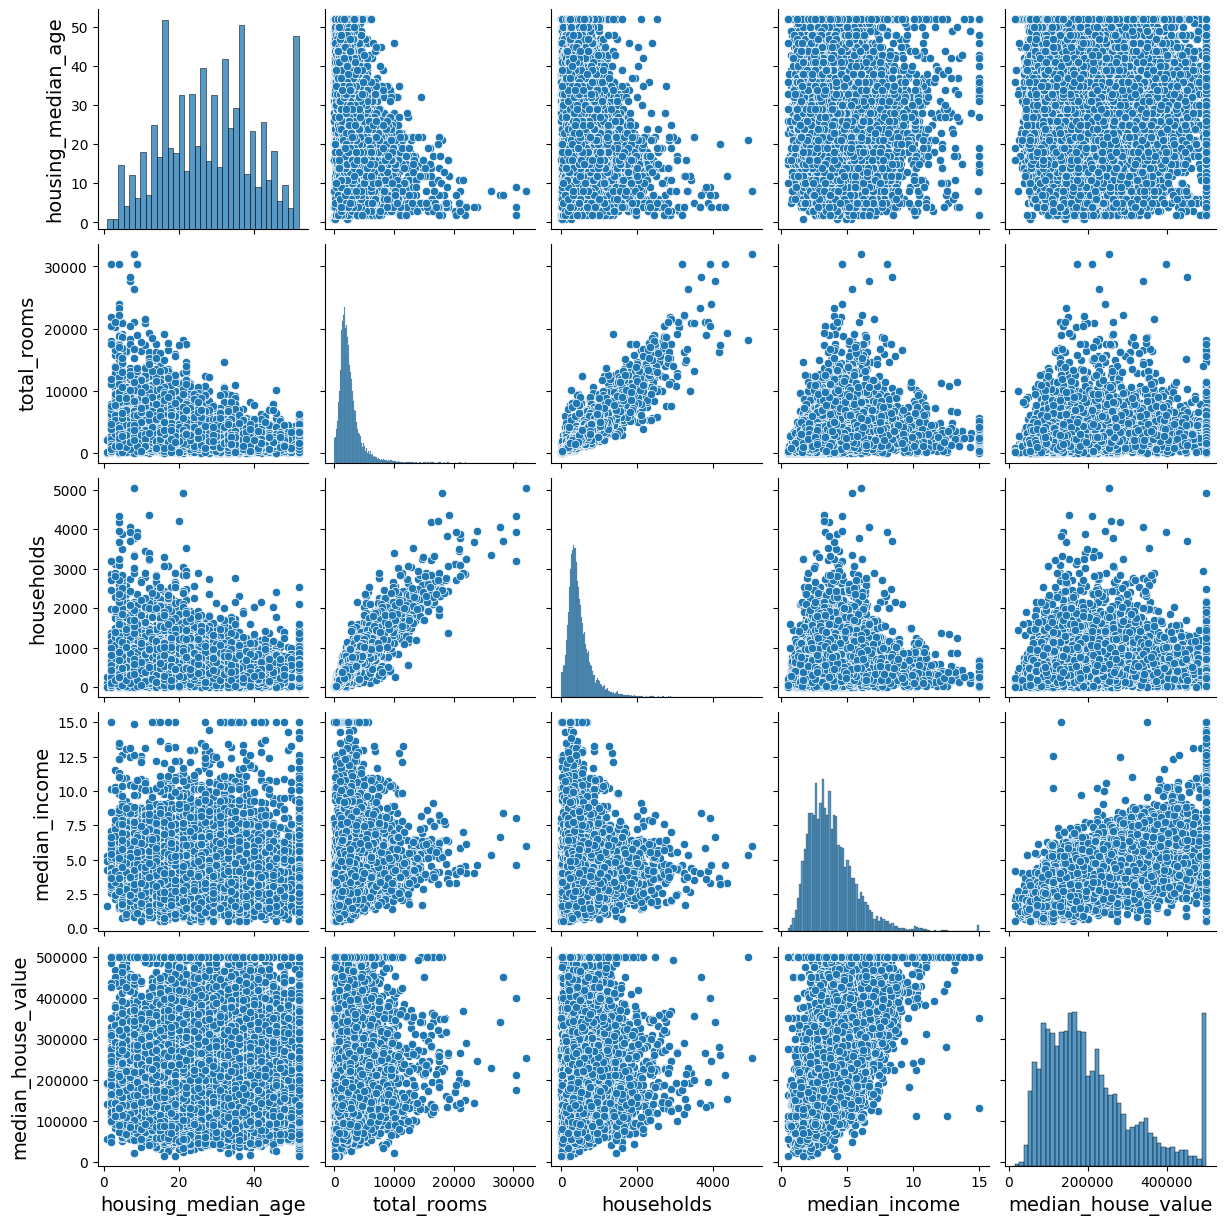

In [33]:
sns.pairplot(train_set[columnas]);

In [34]:
train_set["rooms_per_house"] = train_set["total_rooms"] / train_set["households"]
train_set["bedrooms_ratio"] = train_set["total_bedrooms"] / train_set["total_rooms"]
train_set["people_per_house"] = train_set["population"] / train_set["households"]

In [35]:
corr_matrix = train_set.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.690107
rooms_per_house       0.144667
total_rooms           0.143421
housing_median_age    0.104802
households            0.075800
total_bedrooms        0.059607
population           -0.014545
people_per_house     -0.032066
longitude            -0.042341
latitude             -0.148180
bedrooms_ratio       -0.252394
Name: median_house_value, dtype: float64

In [36]:
### Features iniciales


features = ["ocean_proximity", "income_cat", "rooms_per_house","total_rooms","housing_median_age","bedrooms_ratio"]
features_num = ["rooms_per_house","total_rooms","housing_median_age","bedrooms_ratio"]
target = "median_house_value"

### Tratamiento de variables categóricas

#### Ordinal Encoding

In [37]:
train_set["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     7183
INLAND        5230
NEAR OCEAN    2090
NEAR BAY      1840
ISLAND           3
Name: count, dtype: int64

In [38]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()

train_set["ordinal_ocean"] = ordinal_encoder.fit_transform(train_set[["ocean_proximity"]])

In [39]:
train_set[["ordinal_ocean","ocean_proximity"]].sample(30)

,ordinal_ocean,ocean_proximity
7776,3.0,NEAR BAY
11206,0.0,<1H OCEAN
4750,1.0,INLAND
2571,0.0,<1H OCEAN
4971,0.0,<1H OCEAN
16556,1.0,INLAND
996,0.0,<1H OCEAN
16879,0.0,<1H OCEAN
10681,0.0,<1H OCEAN
2700,3.0,NEAR BAY


In [40]:
categories = [["ISLAND","NEAR OCEAN","NEAR BAY","<1H OCEAN","INLAND"]]

ordinal_encoder = OrdinalEncoder(categories= categories)

train_set["ordinal_ocean"] = ordinal_encoder.fit_transform(train_set[["ocean_proximity"]])

In [41]:
train_set.ordinal_ocean.value_counts()

ordinal_ocean
3.0    7183
4.0    5230
1.0    2090
2.0    1840
0.0       3
Name: count, dtype: int64

In [42]:
train_set[["ordinal_ocean","ocean_proximity"]].sample(30)

,ordinal_ocean,ocean_proximity
13888,2.0,NEAR BAY
16320,1.0,NEAR OCEAN
1936,4.0,INLAND
15390,1.0,NEAR OCEAN
19814,2.0,NEAR BAY
2925,4.0,INLAND
5912,1.0,NEAR OCEAN
2682,1.0,NEAR OCEAN
12144,2.0,NEAR BAY
16565,3.0,<1H OCEAN


#### One-hot encoding

In [43]:
pd.get_dummies(train_set, columns=["ocean_proximity"]).head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,income_cat,rooms_per_house,bedrooms_ratio,people_per_house,ordinal_ocean,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
17371,-118.82,34.15,9.0,655.0,110.0,222.0,109.0,7.8528,337500.0,5,6.009174,0.167939,2.036697,1.0,False,False,False,False,True
17521,-122.40,37.72,47.0,1167.0,250.0,953.0,253.0,4.2727,241900.0,3,4.612648,0.214225,3.766798,2.0,False,False,False,True,False
19022,-122.27,37.78,45.0,1169.0,263.0,723.0,286.0,3.9444,212900.0,3,4.087413,0.224979,2.527972,2.0,False,False,False,True,False
16921,-117.92,33.98,10.0,16414.0,2919.0,8907.0,2714.0,6.1552,362500.0,5,6.047900,0.177836,3.281872,3.0,True,False,False,False,False
9068,-117.20,33.12,18.0,4372.0,736.0,1473.0,675.0,5.1194,247800.0,4,6.477037,0.168344,2.182222,1.0,False,False,False,False,True


In [44]:
train_set_bck = train_set.copy()
train_set = pd.get_dummies(train_set, columns = ["ocean_proximity"], dtype = int)

In [45]:
train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,income_cat,rooms_per_house,bedrooms_ratio,people_per_house,ordinal_ocean,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
17371,-118.82,34.15,9.0,655.0,110.0,222.0,109.0,7.8528,337500.0,5,6.009174,0.167939,2.036697,1.0,0,0,0,0,1
17521,-122.40,37.72,47.0,1167.0,250.0,953.0,253.0,4.2727,241900.0,3,4.612648,0.214225,3.766798,2.0,0,0,0,1,0
19022,-122.27,37.78,45.0,1169.0,263.0,723.0,286.0,3.9444,212900.0,3,4.087413,0.224979,2.527972,2.0,0,0,0,1,0
16921,-117.92,33.98,10.0,16414.0,2919.0,8907.0,2714.0,6.1552,362500.0,5,6.047900,0.177836,3.281872,3.0,1,0,0,0,0
9068,-117.20,33.12,18.0,4372.0,736.0,1473.0,675.0,5.1194,247800.0,4,6.477037,0.168344,2.182222,1.0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17615,-118.13,33.93,19.0,1793.0,447.0,1222.0,452.0,2.6862,195800.0,2,3.966814,0.249303,2.703540,3.0,1,0,0,0,0
1747,-118.42,33.92,25.0,3521.0,852.0,1524.0,764.0,3.8086,361300.0,3,4.608639,0.241977,1.994764,3.0,1,0,0,0,0
8827,-118.25,33.79,34.0,1349.0,371.0,1716.0,380.0,2.7143,138100.0,2,3.550000,0.275019,4.515789,1.0,0,0,0,0,1
11504,-121.07,37.71,39.0,223.0,37.0,92.0,37.0,3.3750,212500.0,3,6.027027,0.165919,2.486486,4.0,0,1,0,0,0


In [46]:
train_set["income_cat"].value_counts(True)

income_cat
3    0.350239
2    0.318855
4    0.176740
5    0.114340
1    0.039826
Name: proportion, dtype: float64

In [47]:
features_cat = [col for col in train_set.columns if "ocean_proximity" in col] + ["income_cat"]
features_cat

['ocean_proximity_<1H OCEAN',
 'ocean_proximity_INLAND',
 'ocean_proximity_ISLAND',
 'ocean_proximity_NEAR BAY',
 'ocean_proximity_NEAR OCEAN',
 'income_cat']

### Tratamiento numéricas

#### Min-Max Scaling

$$
[0,1]\quad \hat{x}_i = \frac{x_i - x_{\min}}{x_{\max} - x_{\min}}
$$

$$
[-1,1]\quad \hat{x}_i = 2\frac{x_i - x_{\min}}{x_{\max} - x_{\min}} - 1
$$

$$
[a,b]\quad \hat{x}_i = (b-a)\frac{x_i - x_{\min}}{x_{\max} - x_{\min}} + a
$$


In [48]:
from sklearn.preprocessing import MinMaxScaler

features_num = ["rooms_per_house","total_rooms","housing_median_age","bedrooms_ratio"]
min_max_scaler = MinMaxScaler(feature_range=(-1, 1))

resultado_min_max = pd.DataFrame(min_max_scaler.fit_transform(train_set[features_num]), columns= features_num)
resultado_min_max

,rooms_per_house,total_rooms,housing_median_age,bedrooms_ratio
0,-0.926798,-0.959254,-0.686275,-0.849025
1,-0.946598,-0.927306,0.803922,-0.746168
2,-0.954045,-0.927181,0.725490,-0.722270
3,-0.926249,0.024086,-0.647059,-0.827031
4,-0.920165,-0.727318,-0.333333,-0.848124
...,...,...,...,...
16341,-0.955755,-0.888244,-0.294118,-0.668216
16342,-0.946655,-0.780419,-0.058824,-0.684496
16343,-0.961665,-0.915949,0.294118,-0.611070
16344,-0.926545,-0.986210,0.490196,-0.853513


In [49]:
resultado_min_max.describe()

,rooms_per_house,total_rooms,housing_median_age,bedrooms_ratio
count,16346.000000,16346.000000,16346.000000,16346.000000
mean,-0.934956,-0.835624,0.083793,-0.749071
std,0.035830,0.134105,0.493885,0.129153
min,-1.000000,-1.000000,-1.000000,-1.000000
25%,-0.948969,-0.909881,-0.333333,-0.832600
50%,-0.937710,-0.867403,0.098039,-0.771222
75%,-0.926181,-0.803569,0.411765,-0.689815
max,1.000000,1.000000,1.000000,1.000000


#### Standardization

$$x_i = \dfrac{x - \bar x}{s_x}\ \text{,donde } s_x \text{ es la desviación estándar de la variable numérica}$$

In [50]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
#std_scaler.fit(train_set[features_num])

resultado_standardization = pd.DataFrame(std_scaler.fit_transform(train_set[features_num]),columns = features_num)
resultado_standardization.head()

,rooms_per_house,total_rooms,housing_median_age,bedrooms_ratio
0,0.227669,-0.921912,-1.559253,-0.773940
1,-0.324952,-0.683673,1.458134,0.022478
2,-0.532794,-0.682743,1.299324,0.207520
3,0.242993,6.410896,-1.479848,-0.603645
4,0.412808,0.807643,-0.844609,-0.766970


In [51]:
resultado_standardization.describe()

,rooms_per_house,total_rooms,housing_median_age,bedrooms_ratio
count,1.634600e+04,1.634600e+04,1.634600e+04,1.634600e+04
mean,-1.151926e-17,-2.955886e-17,-1.630084e-17,1.721369e-16
std,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00
min,-1.815397e+00,-1.225759e+00,-2.194493e+00,-1.942939e+00
25%,-3.911216e-01,-5.537357e-01,-8.446088e-01,-6.467622e-01
50%,-7.686551e-02,-2.369764e-01,2.884537e-02,-1.715193e-01
75%,2.448887e-01,2.390349e-01,6.640848e-01,4.588176e-01
max,5.400482e+01,1.368833e+01,1.855159e+00,1.354302e+01


#### Transformacion distribuciones

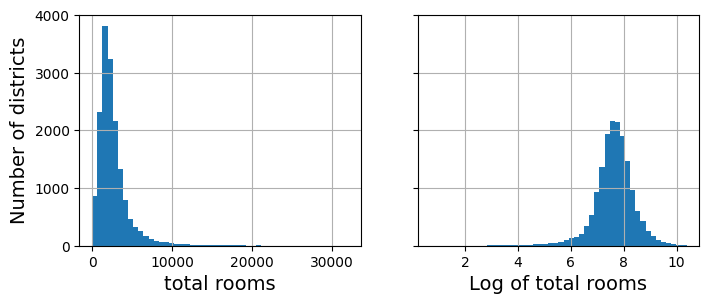

In [52]:

fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
train_set["total_rooms"].hist(ax=axs[0], bins=50)
train_set["total_rooms"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("total rooms")
axs[1].set_xlabel("Log of total rooms")
axs[0].set_ylabel("Number of districts")
plt.show()

In [53]:

for col in ["rooms_per_house","total_rooms","bedrooms_ratio"]:
    train_set[f"log_{col}"] = train_set[col].apply(np.log)
    train_set[col] = min_max_scaler.fit_transform(train_set[[f"log_{col}"]])

train_set["housing_median_age"] = min_max_scaler.fit_transform(train_set[["housing_median_age"]])

array([[<Axes: title={'center': 'rooms_per_house'}>,
        <Axes: title={'center': 'total_rooms'}>],
       [<Axes: title={'center': 'housing_median_age'}>,
        <Axes: title={'center': 'bedrooms_ratio'}>]], dtype=object)

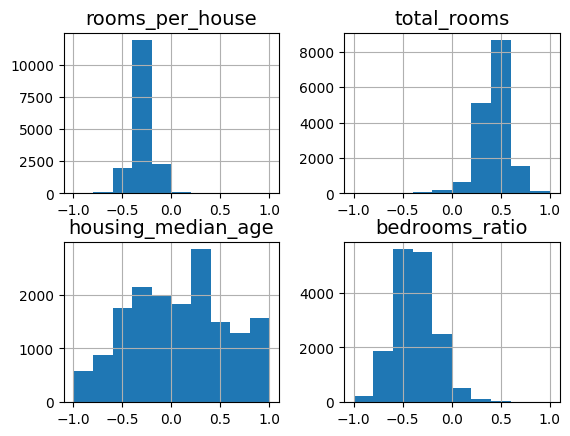

In [54]:
f_num = ["rooms_per_house","total_rooms","housing_median_age","bedrooms_ratio"]
train_set[f_num].hist()

### Modelado

In [55]:
features

['ocean_proximity',
 'income_cat',
 'rooms_per_house',
 'total_rooms',
 'housing_median_age',
 'bedrooms_ratio']

Oye antes del modelo si yo ahora te digo que una zona tiene:
inland, 3, 2.5, 5, 23, 1.2 -> min()

In [56]:
train_set.median_house_value.mean()

np.float64(207112.11837758473)

In [57]:
from sklearn.metrics import root_mean_squared_error #RMSE #MSE

In [58]:
y_pred = 2500 * train_set["rooms_per_house"]

In [59]:
root_mean_squared_error(train_set["median_house_value"],y_pred)

237980.49679797882

BASELINE

In [60]:
# Regresor Lineal

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

# Arboles de decisión para Regresión 
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state = 42) # Necesita una inicialización aleatoria y la semilla permite que siempre sea la misma

In [61]:
features_cat = [col for col in train_set if col.startswith("ocean_proximity")] + ["income_cat"]

In [62]:
features = features_cat + features_num

In [63]:
X = train_set[features].copy() # ojo, es train, está bien
y= train_set[target] # ojo, es train, está bien

In [64]:
lin_reg.fit(X,y)
tree_reg.fit(X,y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

¿Algua predicción en especial? (audience request :-))

### Evaluación contra Train (train_error):

In [65]:
# Primero las predicciones
train_pred_lin = lin_reg.predict(X)

train_pred_tree = tree_reg.predict(X)

In [66]:
mse_lin = root_mean_squared_error(y, train_pred_lin) # En realidad damos la raíz cuadrada del error cuadrático medio
# que está en las mismas unidades que el target
print(mse_lin)

77183.912535398


In [67]:
mse_tree = root_mean_squared_error(y, train_pred_tree)
print(mse_tree) # overfitting!!!

0.0


### Validación Cruzada

Nosotros no hemos reservado datos para un set de validación porque hemos comentado que usaríamos validación cruzada. Y eso haremos. Básicamente vamos a reentrenar el los modelos con las dos técnicas elegidas con unos datasets de entrenamiento creados a partir del dataset completo de entrenamiento. Luego evaluaremos esos submodelos para cada ténica y la métrica será la media de las métricas para cada modelo.  

El proceso es el siguiente:

1. Dividiremos el dataset de train en "k" grupos (depende del total de datos que tengamos). 

2. Entrenaremos un modelo para cada combinación de k-1 grupos posibles (si tengo k = 5 por ejemplo tendré 5 posibles combinaciones, ver la tabla más abajo). Evaluaremos con el grupo restante.

3. La métrica a considerar será la media de las obtenidas en cada uno de las evaluaciones hechas.


| Ronda     | Fold 1    | Fold 2    | Fold 3    | Fold 4    | Fold 5    |
|-----------|-----------|-----------|-----------|-----------|-----------|
| 1         | Test      | Training  | Training  | Training  | Training  |
| 2         | Training  | Test      | Training  | Training  | Training  |
| 3         | Training  | Training  | Test      | Training  | Training  |
| 4         | Training  | Training  | Training  | Test      | Training  |
| 5         | Training  | Training  | Training  | Training  | Test      |


In [68]:
from sklearn.model_selection import cross_val_score

lin_rmses = -cross_val_score(lin_reg, X, y,
                              scoring="neg_root_mean_squared_error", cv=10) # k = 10)
print(lin_rmses)
pd.Series(lin_rmses).describe()

[76414.9791569  73907.67702788 78558.51840914 76062.98831396
 75978.29832281 77221.30259421 80142.88743541 79500.89924804
 78377.94727179 76204.23377734]


count       10.000000
mean     77236.973156
std       1897.577073
min      73907.677028
25%      76098.299680
50%      76818.140876
75%      78513.375625
max      80142.887435
dtype: float64

In [69]:
tree_rmses = -cross_val_score(tree_reg, X, y,
                              scoring="neg_root_mean_squared_error", cv=10) # k = 10
print(tree_rmses)
pd.Series(tree_rmses).describe()

[ 95734.11600509  96852.89976036 101699.52683142  96065.30662939
  94945.8637771   97783.37040252 101613.79460751 102168.76010939
  96649.68321998  98065.57858891]


count        10.000000
mean      98157.889993
std        2693.009854
min       94945.863777
25%       96211.400777
50%       97318.135081
75%      100726.740603
max      102168.760109
dtype: float64

### Evaluación contra test (test_error)

In [71]:
test_set["income_cat"] = pd.cut(test_set["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

test_set["rooms_per_house"] = test_set["total_rooms"] / test_set["households"]
test_set["bedrooms_ratio"] = test_set["total_bedrooms"] / test_set["total_rooms"]



target = "median_house_value"

# Procesado de variables categóricas
test_set = pd.get_dummies(test_set, columns = ["ocean_proximity"], dtype = int)

# Procesado de variables numéricas
min_max_scaler = MinMaxScaler(feature_range=(-1, 1)) # ESTO NO ES FORMALMENTE CORRECTO, lo veremos en la sesión en vivo
for col in ["rooms_per_house","total_rooms","bedrooms_ratio"]:
    test_set[f"log_{col}"] = test_set[col].apply(np.log)
    test_set[col] = min_max_scaler.transform(test_set[[f"log_{col}"]]) # ¡ojo! debería ser transform

test_set["housing_median_age"] = min_max_scaler.transform(test_set[["housing_median_age"]]) # ¡ojo! debería ser transform


# Features finales
features = ['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN', "income_cat", "rooms_per_house","total_rooms","housing_median_age","bedrooms_ratio"]


X_test = test_set[features].copy()
y_test = test_set[target]

KeyError: "None of [Index(['ocean_proximity'], dtype='str')] are in the [columns]"

In [ ]:
test_predict = lin_reg.predict(X_test)
mse_lin_test = root_mean_squared_error(y_test, test_predict)
print(mse_lin_test)

75697.80970098067


In [ ]:
test_predict = tree_reg.predict(X_test)
mse_tree_test = root_mean_squared_error(y_test, test_predict)
print(mse_tree_test)

104807.54336162264


### Overfitting, Underfitting, Bias, Variance

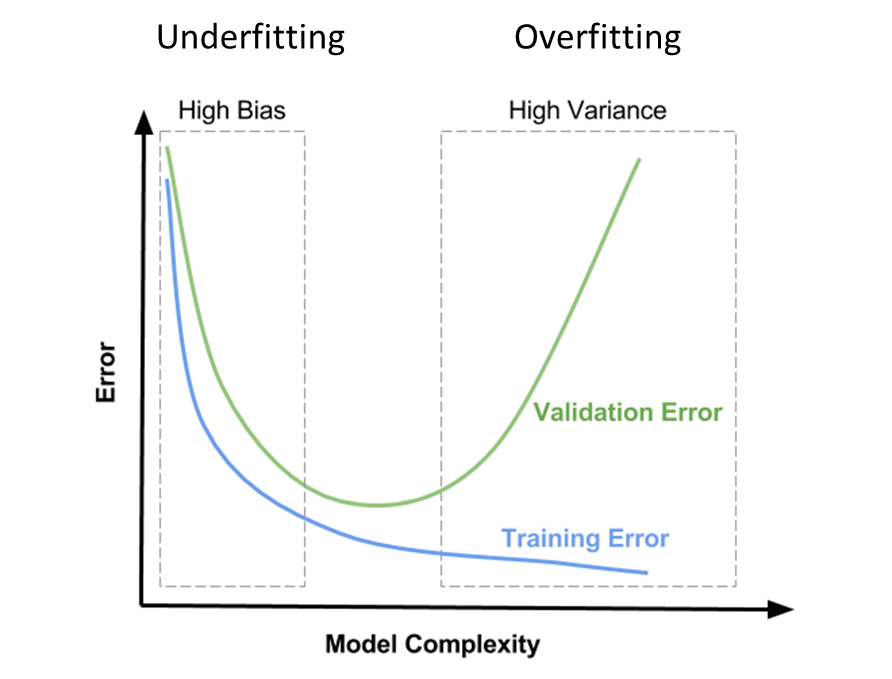

**Overfitting**: Ocurre cuando un modelo de aprendizaje automático se entrena demasiado bien con los datos de entrenamiento, memorizándolos en lugar de aprender de ellos. Esto lleva a una mala generalización a nuevos datos.  

**Underfitting**: Sucede cuando un modelo es demasiado simple para capturar la estructura de los datos, resultando en un rendimiento pobre tanto en entrenamiento como en generalización.  

**Bias**: Error por simplificación excesiva, asumiendo relaciones más simples de lo que realmente son, lo que conduce a underfitting.  
  
**Variance**: Error por complejidad excesiva, prestando demasiada atención a los datos de entrenamiento, incluido el ruido, lo que lleva a overfitting.  
  
**Trade-off Bias/Variance**: Equilibrio entre bias y variance. Se busca un modelo con bajo bias (capaz de capturar la verdadera relación) y baja variance (que no sea excesivamente complejo), lo cual es clave para un modelo efectivo.


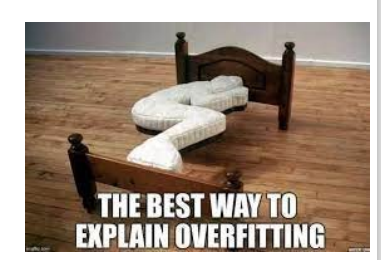